# Data Preparation and EDA

This notebook covers:
- Step 1: Data understanding (basic inspection)
- Step 2: Data aggregation for EV market share
- Step 3: EDA, decomposition, and logit transform

In [133]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.seasonal import seasonal_decompose

plt.style.use("seaborn-v0_8")

In [134]:
df_raw = pd.read_csv("China Automobile Sales Data.csv")
df_raw.head()

,model,units_sold,make,low_price,high_price,year_month,is_ev,body_type,brand,brand_country
0,Model Y,69098,特斯拉中国,316.9,417.9,2022-11-01,EV,SUV,Tesla,United States
1,宏光MINIEV,68567,上汽通用五菱,32.8,99.9,2022-11-01,EV,Hatchback,Wuling Motors,China
2,宋PLUS新能源,64145,比亚迪,152.8,216.8,2022-11-01,EV,SUV,BYD,China
3,汉,31786,比亚迪,214.8,329.8,2022-11-01,EV,Sedan,BYD,China
4,Model 3,31193,特斯拉中国,266.7,339.9,2022-11-01,EV,Sedan,Tesla,United States


We only need to focus on three columns: `units_sold`, `year_month`, and `is_ev`.
* `units_sold`: total units of each model sold in one month
* `year_month`: the recorded year and month
* `is_ev`: indicates whether the model is an EV or gasoline vehicle

In [135]:
df_raw.info()
df_raw.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38806 entries, 0 to 38805
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   model          38806 non-null  object 
 1   units_sold     38806 non-null  int64  
 2   make           38806 non-null  object 
 3   low_price      38806 non-null  float64
 4   high_price     38806 non-null  float64
 5   year_month     38806 non-null  object 
 6   is_ev          38806 non-null  object 
 7   body_type      36440 non-null  object 
 8   brand          38806 non-null  object 
 9   brand_country  38806 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 3.0+ MB


model               0
units_sold          0
make                0
low_price           0
high_price          0
year_month          0
is_ev               0
body_type        2366
brand               0
brand_country       0
dtype: int64

* Dataset has 38806 rows and 10 columns
* `body type` has 2366 missing values, but no handling is needed because that column is not used

In [136]:
df_raw[df_raw.duplicated()].head()

,model,units_sold,make,low_price,high_price,year_month,is_ev,body_type,brand,brand_country
3260,东南DX7,1,东南汽车,99.9,139.9,2023-04-01,Gasoline,SUV,Southeast,China
3261,冒险家新能源,1,长安林肯,309.8,345.8,2023-04-01,EV,SUV,Lincoln,United States
5404,沃尔沃S60新能源,38,沃尔沃亚太,399.9,461.9,2023-08-01,EV,Sedan,Volvo,Sweden
6002,奥迪A6L新能源,3,一汽-大众奥迪,508.0,508.0,2023-09-01,EV,Sedan,Audi,Germany
6956,蔚来EC7,350,蔚来,458.0,548.0,2023-11-01,EV,NaN,NIO,China


In [137]:
df_raw = df_raw.drop_duplicates()

A total of 33 fully duplicated observations were identified and removed to prevent double counting during monthly aggregation

In [138]:
df_raw["units_sold"] = (
    df_raw["units_sold"]
    .astype(str)
    .str.replace(",", "", regex=False)
)
df_raw["units_sold"] = pd.to_numeric(df_raw["units_sold"], errors="coerce")

print("Missing units_sold after convert:", df_raw["units_sold"].isna().sum())
print("Negative units_sold:", (df_raw["units_sold"] < 0).sum())

Missing units_sold after convert: 0
Negative units_sold: 0


In [139]:
df_raw['units_sold'].describe()

count    38773.000000
mean      3529.806051
std       5884.277544
min          1.000000
25%        259.000000
50%       1219.000000
75%       4106.000000
max      73009.000000
Name: units_sold, dtype: float64

Based on the descriptive statistics results, `units_sold` contains reasonable positive values (`Min >= 1`). Although the maximum values are large, they realistically reflect the best-selling vehicle models in the market. Therefore, no data entry errors were identified, and 100% of the raw data was preserved for the aggregation step.

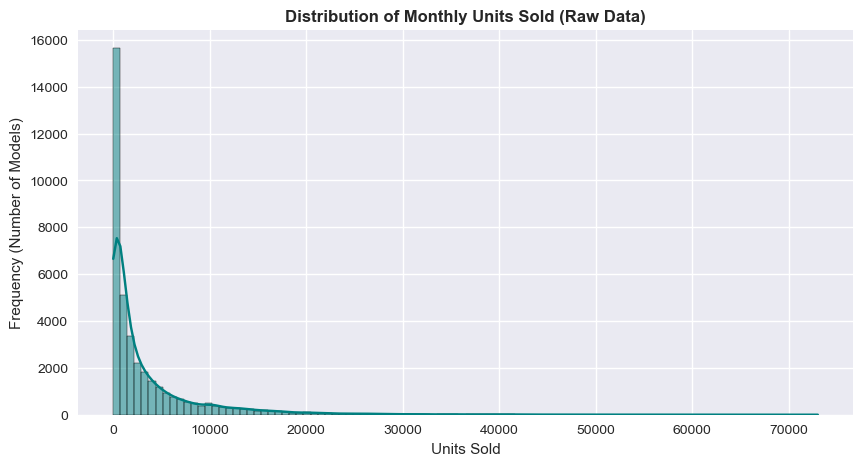

In [140]:
plt.figure(figsize=(10, 5))
sns.histplot(df_raw['units_sold'], bins=100, kde=True, color='teal')
plt.title('Distribution of Monthly Units Sold (Raw Data)', fontweight='bold')
plt.xlabel('Units Sold')
plt.ylabel('Frequency (Number of Models)')
plt.show()

The distribution of the original data is clearly right-skewed, accurately reflecting the Pareto principle in the automotive market: a small number of popular vehicle models account for the majority of total market sales

## Aggregate monthly data

In [141]:
df_raw['is_ev'].value_counts()

is_ev
Gasoline    30258
EV           8515
Name: count, dtype: int64

In [142]:
df = df_raw.copy()
df["year_month"] = pd.to_datetime(df["year_month"], errors="coerce")
df = df.dropna(subset=["year_month"])

# Aggregate monthly data
total_sales = df.groupby("year_month")["units_sold"].sum()
ev_sales = df[df["is_ev"] == "EV"].groupby("year_month")["units_sold"].sum()

monthly = pd.concat([total_sales, ev_sales], axis=1)
monthly.columns = ["Total_Sales", "EV_Sales"]

# Force indexing by monthly frequency (month start)
monthly = monthly.asfreq("MS")

# Fill EV_Sales, avoid division by zero
monthly["EV_Sales"] = monthly["EV_Sales"].fillna(0)
monthly["EV_Market_Share"] = np.where(
    monthly["Total_Sales"] > 0,
    monthly["EV_Sales"] / monthly["Total_Sales"],
    np.nan
)

monthly.head()

,Total_Sales,EV_Sales,EV_Market_Share
year_month,,,
2018-01-01,2436495,24480,0.010047
2018-02-01,1469679,23449,0.015955
2018-03-01,2144088,42745,0.019936
2018-04-01,1881043,51110,0.027171
2018-05-01,1887345,60565,0.032090


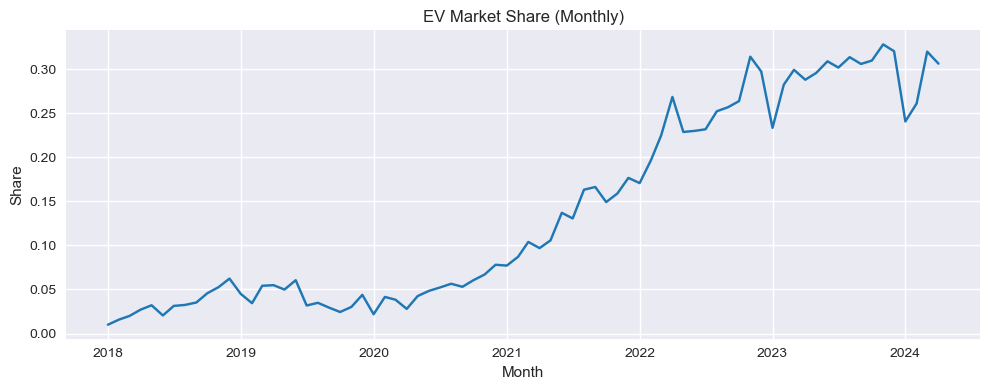

In [143]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly.index, monthly["EV_Market_Share"], color="#1f77b4")
ax.set_title("EV Market Share (Monthly)")
ax.set_ylabel("Share")
ax.set_xlabel("Month")
plt.tight_layout()
plt.show()

* **Primary Growth Trend:** The time series exhibits an extremely strong upward trend. The share of electric vehicles started below 5% (in 2018) and surpassed the 35–40% threshold by early 2024. This is characteristic of a market in a rapid expansion phase.

* **Growth Pattern:** The data does not increase linearly; instead, it shows signs of an **S-curve growth pattern**. The growth rate began accelerating significantly from around 2021 onward.
* **Seasonality:** Sales typically decline sharply at the beginning of the year (January–February due to the Lunar New Year effect) and peak during the final months of the year.
* **Heteroscedasticity:** As the market share values increase, the magnitude of seasonal fluctuations also tends to widen.

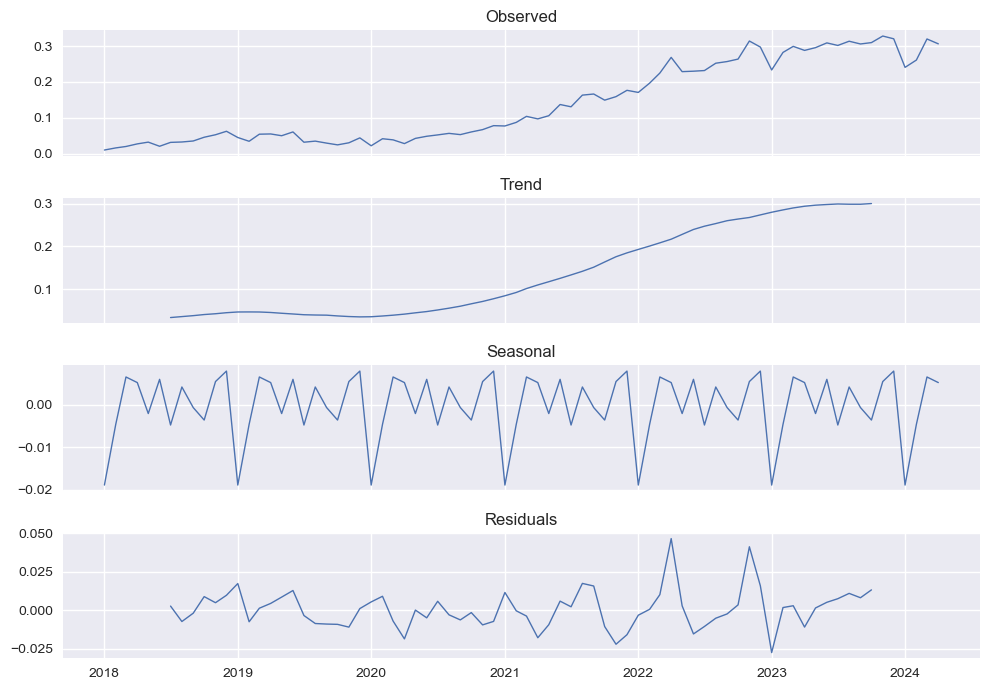

In [144]:
series = monthly["EV_Market_Share"].dropna()
decomp = seasonal_decompose(series, model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(10, 7), sharex=True)

axes[0].plot(series.index, series.values, "-", linewidth=1)
axes[0].set_title("Observed")

axes[1].plot(decomp.trend.index, decomp.trend.values, "-", linewidth=1)
axes[1].set_title("Trend")

axes[2].plot(decomp.seasonal.index, decomp.seasonal.values, "-", linewidth=1)
axes[2].set_title("Seasonal")

axes[3].plot(decomp.resid.index, decomp.resid.values, "-", linewidth=1)
axes[3].set_title("Residuals")

plt.tight_layout()
plt.show()

* **Observed:** The chart shows strong growth; however, the path is highly jagged, indicating that the data is mixed between the underlying trend and short-term fluctuations.

* **Trend:** After filtering out noise and seasonality, the Trend line reveals a smooth upward curve. This confirms that the market is in the explosive growth phase of the Technology Adoption Lifecycle.
* **Seasonal:** The repeatedly oscillating wave pattern around the zero axis clearly demonstrates that the data has **strong seasonality with a 12-month cycle**.
* **Residuals:** Most of the data fluctuates randomly around the zero level. However, a few noticeable spikes can be visually observed standing out prominently (particularly during the middle and end of 2022).

In [145]:
print("Check Outliers in Residuals:")

residuals = decomp.resid.dropna()

mean_resid = residuals.mean()
std_resid = residuals.std()
lower_bound = mean_resid - 3 * std_resid
upper_bound = mean_resid + 3 * std_resid

time_series_outliers = residuals[(residuals < lower_bound) | (residuals > upper_bound)]

if len(time_series_outliers) == 0:
    print("-> Result: NO macroeconomic shocks were detected. The residuals fluctuated stably within the 3-sigma threshold")
    print("-> Data is clean and ready for SARIMA modeling")
else:
    print(f"-> Result: {len(time_series_outliers)} months with abnormal fluctuations detected:")
    print(time_series_outliers)

Check Outliers in Residuals:
-> Result: 2 months with abnormal fluctuations detected:
year_month
2022-04-01    0.046484
2022-11-01    0.041164
Name: resid, dtype: float64


* **April 2022 (Shanghai Lockdown Event):**
This was the peak of the COVID-19 outbreak, when China implemented strict Zero-COVID lockdown measures across several major industrial centers. Supply chain disruptions caused total automobile sales to collapse sharply across the market. However, some domestic EV manufacturers (such as BYD), which had greater control over their supply chains, were less affected. As the “denominator” (total vehicle sales) dropped significantly while the “numerator” (EV sales) declined less severely, the EV market share percentage surged to an unusually high local level.

* **November 2022 (Pre-Subsidy Removal “Rush” Shock):**
The Chinese government officially announced the complete termination of national EV purchase subsidies effective December 31, 2022. To take advantage of the final opportunity for incentives, consumers rushed to purchase EVs during November and December. This represents a typical policy-driven demand shock, causing EV market share to rise far beyond its normal growth and seasonal patterns.

In [146]:
epsilon = 1e-6
share = monthly["EV_Market_Share"].clip(epsilon, 1 - epsilon)
monthly["EV_Market_Share_Logit"] = np.log(share / (1 - share))
monthly[["EV_Market_Share", "EV_Market_Share_Logit"]].head()

,EV_Market_Share,EV_Market_Share_Logit
year_month,,
2018-01-01,0.010047,-4.590361
2018-02-01,0.015955,-4.121888
2018-03-01,0.019936,-3.895080
2018-04-01,0.027171,-3.578054
2018-05-01,0.032090,-3.406593


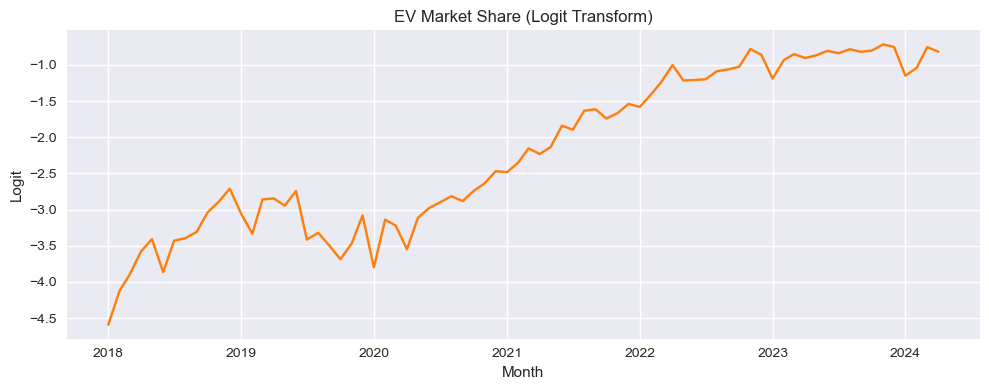

In [147]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly.index, monthly["EV_Market_Share_Logit"], color="#ff7f0e")
ax.set_title("EV Market Share (Logit Transform)")
ax.set_ylabel("Logit")
ax.set_xlabel("Month")
plt.tight_layout()
plt.show()

**1. The Problem with the Original Data:**
The target variable, `EV_Market_Share`, is a percentage ratio strictly bounded within the interval $(0, 1)$. In addition, the market share curve exhibits the shape of a Logistic (S-curve) function. Feeding this raw data directly into a SARIMA model could lead to biased estimations or unrealistic forecasts (e.g., predicted market share greater than 100% or below 0%).

**2. The Solution – Logit Transformation:**
A Logit transformation was applied to map the data from the interval $(0, 1)$ onto the real-number domain $(-\infty, +\infty)$ using the following formula:

$$y' = \ln\left(\frac{y}{1-y}\right)$$

**3. The Result:**
From the transformed plot, the growth curve becomes significantly more linearized, while the heteroscedasticity issue is also substantially reduced. At this stage, the transformed time series `EV_Market_Share_Logit` fully satisfies the strict mathematical assumptions required for identification and stationarity testing within the Box–Jenkins (SARIMA) modeling framework.

In [148]:
out_path = Path("ev_market_share.csv")
monthly.to_csv(out_path)

out_path

WindowsPath('ev_market_share.csv')